## If working in Google Colab, Run this first
Run the cell below, at the start of every session. 
It downloads the course files to your Google Drive and keeps them up to date.
When you see \"Setup complete\", you are ready to run the rest of the notebook.

**Do not edit or save your work inside the `AIforMovementScience` folder.** 
Use **File > Save a copy in Drive** and work on your own copy.

In [ ]:
# [course-setup] Run this cell first, every session (or use Runtime > Run all)
import os, sys
os.chdir('/content')                      # start from a valid directory
from google.colab import drive
drive.mount('/content/drive')

REPO = '/content/drive/MyDrive/AIforMovementScience'
if os.path.isdir(REPO + '/.git'):
    # already downloaded before: just update it
    !git -C "$REPO" fetch origin main && git -C "$REPO" reset --hard origin/main
else:
    # first time, or a broken/partial copy: download a fresh copy
    !rm -rf "$REPO"
    !git clone https://github.com/dguari1/AIforMovementScience.git "$REPO"

WORKDIR = REPO + '/lectures'          # this notebook's folder in the course files
os.chdir(WORKDIR)
sys.path.insert(0, WORKDIR)           # so local .py files (e.g. FunctionExamples.py) import correctly
print('Setup complete. You can now run the rest of the notebook.')

# 03.05 - Gait Analysis: Coding Activity

In this activity, you will use **acceleration** and **EMG** signals recorded during walking to answer one question:

> **When is each lower-leg muscle active during the gait cycle?**

You will use the same pipeline that you learned in 03.04, but with a new type of signal (EMG):

1. Detect heel strikes from the acceleration signal
2. Find the same heel strikes in the EMG signal (the two signals have different sampling rates)
3. Process the EMG signal to get its envelope
4. Cut the envelope into strides and normalize each stride to 0 to 100%
5. Compute the ensemble average (mean ± SD) across strides
6. **Repeat the analysis for the other muscles** and compare them

---

### How to use this notebook

- Run the cells in order, from top to bottom.
- Cells marked **TODO** have blanks (`...`) that you must complete. Replace each `...` with your code.
- After each part, there is a **Checkpoint**. It tells you what you should see. Do not continue until your result agrees with the checkpoint.
- Cells without TODO are complete. Run them, but you do not need to change them.
- If you are stuck, look at the matching step in **03.04 - Gait Analysis from IMUs**. Most of the code is very similar.

## The data

The file `data/GaitSample.csv` contains data from **four wireless sensors** (Delsys Avanti) placed on the muscles of the **same lower leg** of one participant. The participant walked three times (three **walking bouts**), with pauses between them.

| Sensor | Muscle | Main action |
|---|---|---|
| 5 | Tibialis Anterior (TA) | Dorsiflexion (lifts the toes) |
| 6 | Soleus (SOL) | Plantarflexion (pushes the foot down) |
| 7 | Gastrocnemius Lateral (GL) | Plantarflexion and knee flexion |
| 8 | Gastrocnemius Medial (GM) | Plantarflexion and knee flexion |

Each sensor records **EMG** and **3-axis acceleration** at the same time. All four sensors are synchronized (they use the same clock).

⚠️ **Important: two different sampling rates**
- EMG: about **1926 Hz** (1926 samples per second)
- Acceleration: about **148 Hz** (148 samples per second)

So, in 1 second of data, there are 1926 EMG samples but only 148 acceleration samples. The acceleration columns are much shorter. The file fills the empty rows at the end of the acceleration columns with zeros.

I'm given you a function, `load_sensor()`, that reads the correct columns and removes these zeros. You do not need to change it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['font.size'] = 14   # larger text in the plots

data = pd.read_csv('data/GaitSample.csv')
data.head()

,X [s],Avanti sensor 5: EMG 5 [V],X [s].1,Avanti sensor 5: ACC.X 5 [g],X [s].2,Avanti sensor 5: ACC.Y 5 [g],X [s].3,Avanti sensor 5: ACC.Z 5 [g],X [s].4,Avanti sensor 6: EMG 6 [V],...,X [s].11,Avanti sensor 7: ACC.Z 7 [g],X [s].12,Avanti sensor 8: EMG 8 [V],X [s].13,Avanti sensor 8: ACC.X 8 [g],X [s].14,Avanti sensor 8: ACC.Y 8 [g],X [s].15,Avanti sensor 8: ACC.Z 8 [g]
0,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0,...,0.00000,0.0,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.00000,0.0
1,0.000519,0.0,0.00675,0.0,0.00675,0.0,0.00675,0.0,0.000519,0.0,...,0.00675,0.0,0.000519,0.0,0.00675,0.0,0.00675,0.0,0.00675,0.0
2,0.001038,0.0,0.01350,0.0,0.01350,0.0,0.01350,0.0,0.001038,0.0,...,0.01350,0.0,0.001038,0.0,0.01350,0.0,0.01350,0.0,0.01350,0.0
3,0.001558,0.0,0.02025,0.0,0.02025,0.0,0.02025,0.0,0.001558,0.0,...,0.02025,0.0,0.001558,0.0,0.02025,0.0,0.02025,0.0,0.02025,0.0
4,0.002077,0.0,0.02700,0.0,0.02700,0.0,0.02700,0.0,0.002077,0.0,...,0.02700,0.0,0.002077,0.0,0.02700,0.0,0.02700,0.0,0.02700,0.0


In [2]:
# Sensor number for each muscle
MUSCLES = {
    'Tibialis Anterior': 5,
    'Soleus': 6,
    'Gastrocnemius Lateral': 7,
    'Gastrocnemius Medial': 8,
}

def load_sensor(data, sensor_id):
    '''Return the EMG and acceleration data of one sensor as a dictionary.

    t_emg, emg     : EMG time (s) and EMG signal (V)
    t_acc, acc     : acceleration time (s) and acceleration (g), with columns X, Y, Z
    fs_emg, fs_acc : sampling rates (Hz)
    '''
    cols = list(data.columns)
    i = cols.index(f'Avanti sensor {sensor_id}: EMG {sensor_id} [V]')
    t_emg = data[cols[i - 1]].values
    emg = data[cols[i]].values

    # acceleration: keep only the rows before the zero padding
    t_acc_all = data[cols[i + 1]].values
    n_acc = int(np.argmax(t_acc_all)) + 1          # last row with a valid time
    t_acc = t_acc_all[:n_acc]
    acc = np.column_stack([data[cols[i + 2]].values[:n_acc],    # X
                           data[cols[i + 4]].values[:n_acc],    # Y
                           data[cols[i + 6]].values[:n_acc]])   # Z

    return {'t_emg': t_emg, 'emg': emg, 'fs_emg': 1 / np.median(np.diff(t_emg)),
            't_acc': t_acc, 'acc': acc, 'fs_acc': 1 / np.median(np.diff(t_acc))}

ta = load_sensor(data, MUSCLES['Tibialis Anterior'])
print(f"EMG:          {len(ta['emg'])} samples at {ta['fs_emg']:.0f} Hz")
print(f"Acceleration: {len(ta['t_acc'])} samples at {ta['fs_acc']:.0f} Hz")

EMG:          86580 samples at 1926 Hz
Acceleration: 6660 samples at 148 Hz


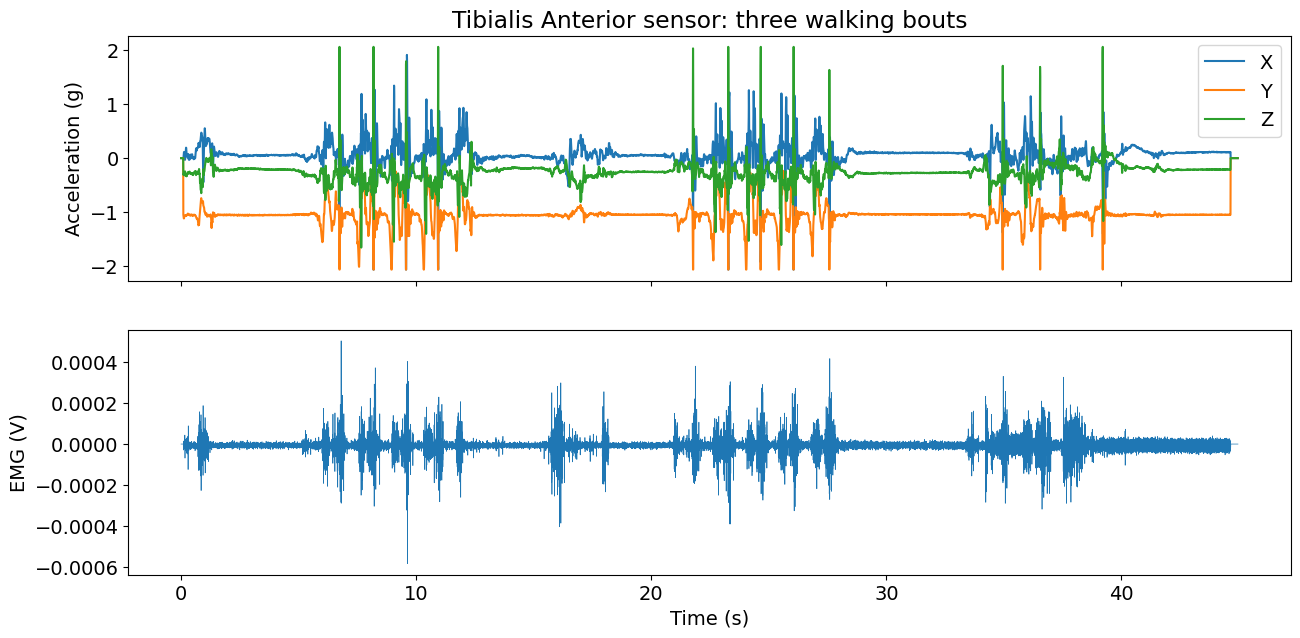

In [4]:
# Look at the full recording from the Tibialis Anterior sensor
fig, ax = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
ax[0].plot(ta['t_acc'], ta['acc'])
ax[0].set_ylabel('Acceleration (g)')
ax[0].legend(['X', 'Y', 'Z'], loc='upper right')
ax[0].set_title('Tibialis Anterior sensor: three walking bouts')
ax[1].plot(ta['t_emg'], ta['emg'], linewidth=0.5)
ax[1].set_ylabel('EMG (V)')
ax[1].set_xlabel('Time (s)')
plt.show()

Can you see the three walking bouts (at about 6 to 12 s, 21 to 28 s, and 34 to 40 s)? The EMG bursts repeat at each stride.

---
## Part 1 - Detect heel strikes

When the heel hits the ground, the impact causes a short, sharp **spike in acceleration**. We will detect these spikes.

We use the **magnitude** of the acceleration (the length of the 3D acceleration vector), so the result does not depend on how the sensor is oriented on the leg:

$$
|a| = \sqrt{a_x^2 + a_y^2 + a_z^2}
$$

**We detect the heel strikes only once.** All four sensors are on the same leg and use the same clock, so the heel strikes are the same for all muscles. We use the Tibialis Anterior sensor because it is on the front of the shin, and its impact spikes are the clearest.

Steps:
- **1a.** Compute the acceleration magnitude.
- **1b.** Apply a 2nd-order low-pass Butterworth filter with a cutoff of **20 Hz** (use `filtfilt`). We use 20 Hz because the impact spike is fast. A 5 Hz filter smooths the spike and moves its peak (remember 03.03).
- **1c.** Use `signal.find_peaks()` to find peaks higher than **1.8 g** that are at least **0.8 s** apart. Remember: `distance` must be in **samples**, not seconds.

In [5]:
# TODO - Part 1
t_acc = ta['t_acc']        # time vector
acc = ta['acc']            # acceleration 3 columns: X, Y, Z
fs_acc = ta['fs_acc']      # sampling rate of the accelerometer 

# 1a. Acceleration magnitude (hint: np.linalg.norm(..., axis =1 ))
acc_mag = np.linalg.norm(acc, axis=1)

# 1b. Low-pass filter, order 2, cutoff 20 Hz (hint: signal.butter(..., btype='low', fs=fs_acc), then signal.filtfilt)
b, a = signal.butter(2, 20/(fs_acc/2), btype='low') #*
acc_mag_filt = signal.filtfilt(b,a, acc_mag)        #*

# 1c. Find the heel strikes (hint: signal.find_peaks(..., height=1.8, distance=int(0.8 * fs_acc))
hs_idx_acc, _ = signal.find_peaks(acc_mag_filt, height=1.8, distance=int(0.8 * fs_acc)) #*

hs_times = t_acc[hs_idx_acc]       # heel strike times in seconds
print(f'Number of heel strikes: {len(hs_idx_acc)}')
print('Heel strike times (s):', np.round(hs_times, 2))

Number of heel strikes: 12
Heel strike times (s): [ 6.74  8.19  9.56 10.94 21.78 23.27 24.65 26.06 27.57 34.94 36.54 39.2 ]


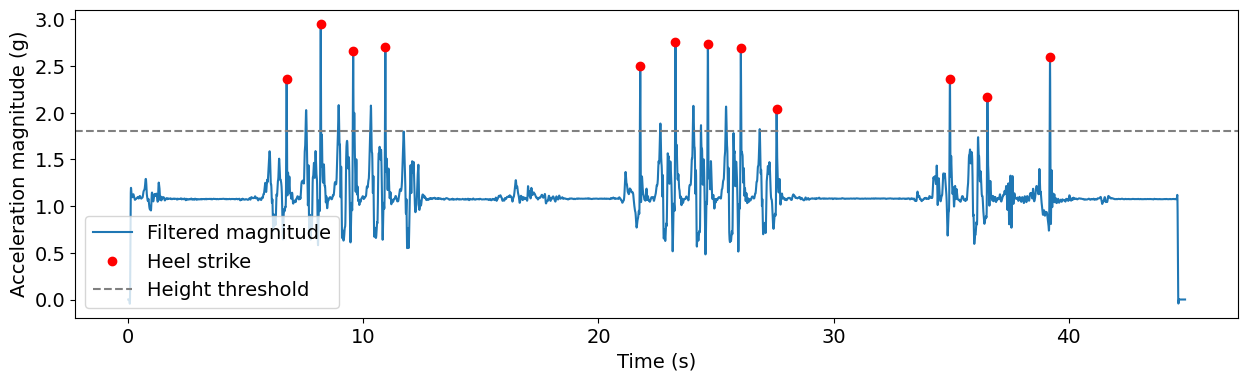

In [7]:
# Check your heel strikes
plt.figure(figsize=(15, 4))
plt.plot(t_acc, acc_mag_filt, label='Filtered magnitude')
plt.plot(hs_times, acc_mag_filt[hs_idx_acc], 'o', color='red', label='Heel strike')
plt.axhline(1.8, linestyle='--', color='gray', label='Height threshold')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration magnitude (g)')
plt.legend(loc='lower left')
plt.show()

### ✅ Checkpoint 1
- You found **12 heel strikes**: 4 in the first bout, 5 in the second bout, and 3 in the third bout.
- Each red dot is on top of a sharp spike.

---
## Part 2 - Find the heel strikes in the EMG signal

`hs_idx_acc` contains **acceleration sample numbers**. You **cannot** use them directly on the EMG signal, because the EMG has many more samples per second.

Example: the heel strike at **21.78 s** is
- acceleration sample number 21.78 × 148 ≈ **3226**
- EMG sample number 21.78 × 1926 ≈ **41,940**

If you used sample 3226 on the EMG signal, you would be at 3226 / 1926 ≈ 1.7 s. That is the wrong time!

**The solution: use time, not sample numbers.** For each heel strike time, find the EMG sample with the same time. `np.searchsorted(t_emg, hs_times)` does this. It returns, for each time in `hs_times`, the index of the first value in `t_emg` that is equal to or larger than that time.

In [8]:
# TODO - Part 2
t_emg = ta['t_emg']
fs_emg = ta['fs_emg']

# Convert the heel strike times to EMG sample numbers (hint: np.searchsorted)
hs_idx_emg = np.searchsorted(t_emg,hs_times)  #*

# Check: the two columns must show (almost) the same times
print('Index for ACC   Time from ACC (s)  Index for EMG  Time from EMG (s)')
for i_a, t_a, i_e in zip(hs_idx_acc, hs_times, hs_idx_emg):
    print(f'{i_a:10.0f} {t_a:15.3f} {i_e:17.0f} {t_emg[i_e]:17.3f}')

Index for ACC   Time from ACC (s)  Index for EMG  Time from EMG (s)
       998           6.737             12974             6.737
      1213           8.188             15769             8.188
      1417           9.565             18421             9.565
      1620          10.935             21060            10.935
      3226          21.776             41938            21.776
      3448          23.274             44824            23.274
      3652          24.651             47476            24.651
      3860          26.055             50180            26.055
      4085          27.574             53105            27.574
      5177          34.945             67301            34.945
      5414          36.544             70382            36.544
      5808          39.204             75504            39.204


### ✅ Checkpoint 2
- The two columns show the same times (a difference smaller than 0.001 s) but different index
- The EMG sample numbers are about 13 times larger than the acceleration sample numbers (1926 / 148 ≈ 13).

---
## Part 3 - Select a muscle and compute the EMG envelope

### 🔁 The `MUSCLE` variable
The next cell has the variable `MUSCLE`. **Parts 3, 4, and 5 use only this variable.** In Part 6, you will change it to analyze a different muscle, and run Parts 3 to 5 again.

### EMG processing
Raw EMG oscillates very fast around zero. To see *how much* the muscle is active, we compute the **envelope** in three steps:

1. **Band-pass filter, 20 to 450 Hz**: keeps the EMG frequencies. It removes movement artifacts (below 20 Hz) and high-frequency noise (above 450 Hz).
2. **Full-wave rectification**: takes the absolute value (`np.abs`), so all values are positive. The sign of the EMG signal carries no information, we only care if the muscle is active and the level of activation.
3. **Low-pass filter, 6 Hz**: smooths the rectified signal. The result is the envelope, a smooth curve that shows the muscle activation.

⚠️ We process the **full** EMG signal first, and cut it into strides after that. Filters do not work well near the start and end of a signal. If you filter many short pieces, you get errors at the start and end of each stride.

In [9]:
MUSCLE = 'Tibialis Anterior'      # Part 6: change this to 'Soleus', 'Gastrocnemius Lateral', or 'Gastrocnemius Medial' to see the behaviour of other muscles

sensor = load_sensor(data, MUSCLES[MUSCLE])
emg = sensor['emg']
print(f'Analyzing: {MUSCLE} (sensor {MUSCLES[MUSCLE]})')

Analyzing: Tibialis Anterior (sensor 5)


In [10]:
def process_emg(emg_signal, fs):
    '''Return the envelope of a raw EMG signal.'''
    # 1. Band-pass filter, 20-450 Hz
    b, a = signal.butter(4, [20, 450], btype='bandpass', fs=fs)
    emg_filtered = signal.filtfilt(b, a, emg_signal)

    # 2. Full-wave rectification
    emg_rectified = np.abs(emg_filtered)

    # 3. Low-pass filter, 6 Hz -> envelope
    b, a = signal.butter(4, 6, btype='low', fs=fs)
    envelope = signal.filtfilt(b, a, emg_rectified)
    return envelope

In [11]:
# TODO - Part 3
# Compute the envelope of the full EMG signal (hint: use the function process_emg with emg and fs_emg)
emg_env = process_emg(emg, fs_emg)

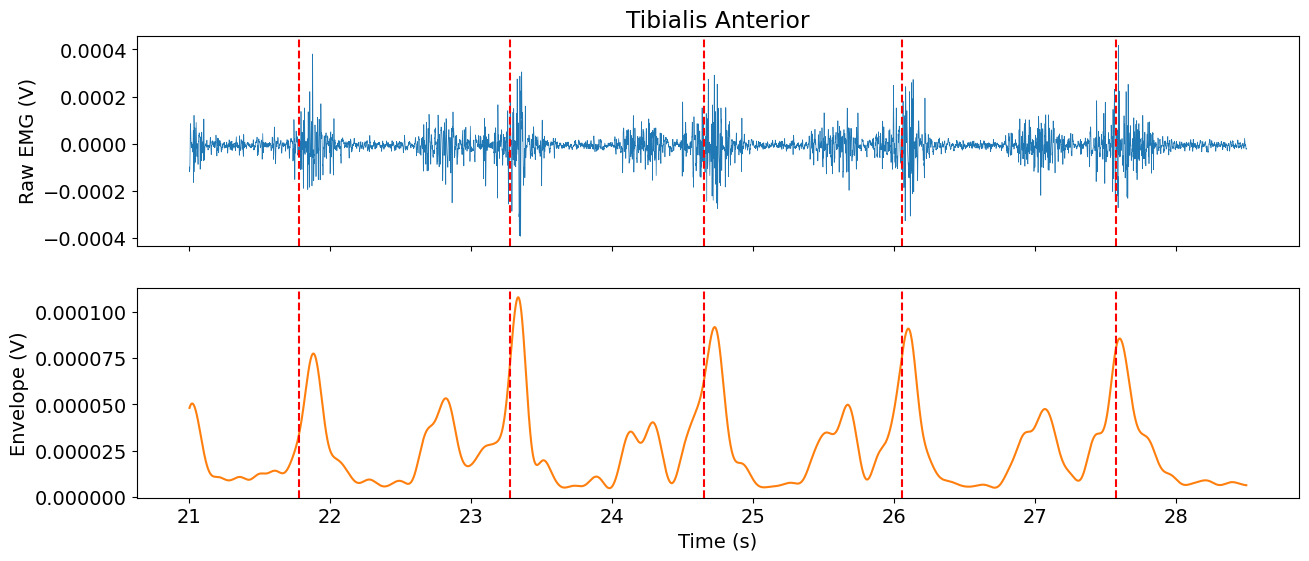

In [12]:
# Check your envelope during the second walking bout
show = (t_emg > 21) & (t_emg < 28.5)
fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
ax[0].plot(t_emg[show], emg[show], linewidth=0.5)
ax[0].set_ylabel('Raw EMG (V)')
ax[0].set_title(MUSCLE)
ax[1].plot(t_emg[show], emg_env[show], color='tab:orange')
ax[1].set_ylabel('Envelope (V)')
ax[1].set_xlabel('Time (s)')
for t_hs in hs_times[(hs_times > 21) & (hs_times < 28.5)]:
    ax[0].axvline(t_hs, color='red', linestyle='--')
    ax[1].axvline(t_hs, color='red', linestyle='--')
plt.show()

### ✅ Checkpoint 3
- The envelope is smooth and always positive.
- The envelope has its peaks where the raw EMG has its bursts.
- The red lines (heel strikes) are at the same position in each stride relative to the bursts. This tells you that the heel strikes and the EMG are aligned.

---
## Part 4 - Cut the envelope into strides and normalize them

All sensors are on **one leg**. So, the time from one heel strike to the **next** heel strike is one **stride** (a full gait cycle of that leg). This is different from 03.04, where the sensor was at the center of mass and detected the heel strikes of both feet.

**Quality check.** Some "strides" are not real strides:
- the time between the last heel strike of one bout and the first heel strike of the next bout (more than 7 s)
- the stride with the missing heel strike in the third bout (about 2.7 s)

A normal stride in this participant lasts about 1.4 s. We keep only the strides between **0.9 s and 2.0 s**.

**Time normalization.** Each stride has a different number of samples. As in 03.04, we use linear interpolation to change each stride to **101 points (0, 1, 2, ..., 100% of the stride)**. Here we use `np.interp(new_x, old_x, old_y)`, which does the same as `interp1d` in 03.04 in one line.

In [13]:
# TODO - Part 4
MIN_STRIDE, MAX_STRIDE = 0.9, 2.0          # seconds
pct = np.linspace(0, 100, 101)             # 0, 1, 2, ..., 100 % of stride

strides = []                               # one normalized stride per item
for k in range(len(hs_idx_emg) - 1):
    start = hs_idx_emg[k]
    end = hs_idx_emg[k + 1]
    stride_time = t_emg[end] - t_emg[start]

    # 4a. Skip the stride if it is shorter than MIN_STRIDE or longer than MAX_STRIDE
    if (stride_time<MIN_STRIDE) or (stride_time>MAX_STRIDE): #*
        continue

    # 4b. Cut the envelope of this stride (from start to end)
    segment = emg_env[start:end] #*

    # 4c. Normalize to 101 points (hint: np.interp(pct, original_pct, segment))
    original_pct = np.linspace(0, 100, len(segment))
    segment_norm = np.interp(pct, original_pct, segment)

    strides.append(segment_norm)

strides = np.array(strides)                # shape: (number of strides, 101)
print(f'Strides kept: {strides.shape[0]} of {len(hs_idx_emg) - 1}')
print(f'Shape of strides: {strides.shape}')

Strides kept: 8 of 11
Shape of strides: (8, 101)


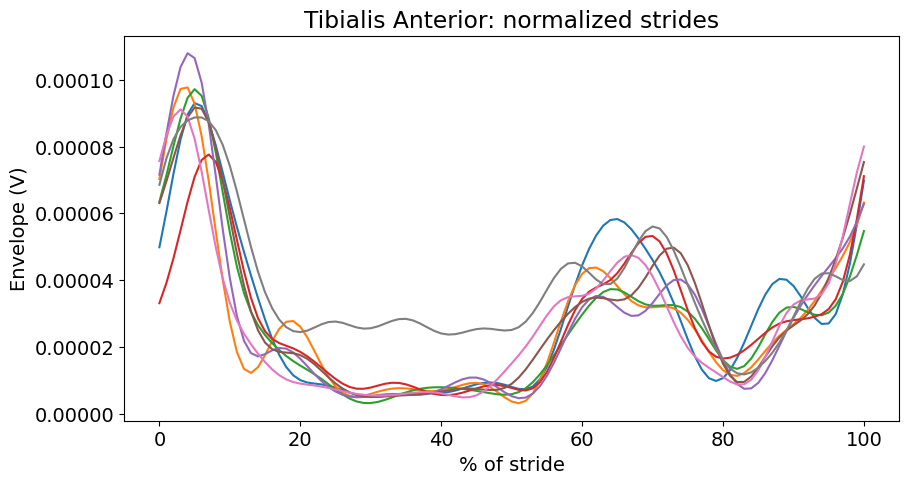

In [14]:
# Check your normalized strides
plt.figure(figsize=(10, 5))
plt.plot(pct, strides.T)
plt.xlabel('% of stride')
plt.ylabel('Envelope (V)')
plt.title(f'{MUSCLE}: normalized strides')
plt.show()

### ✅ Checkpoint 4
- **8 strides** are kept (of 11 possible), and the shape is **(8, 101)**.
- All strides start at 0% and end at 100%, and they have a similar shape.

---
## Part 5 - Ensemble average

Compute the **mean** and the **standard deviation (SD)** of the strides at each % of the stride. Remember: each row of `strides` is one stride, so you must compute along `axis=0`.

In the plot, the dashed line at **about 60%** shows the approximate **toe-off** (the end of stance). From 0 to 60% the foot is on the ground (**stance**). From 60 to 100% the foot is in the air (**swing**).

In [15]:
# TODO - Part 5
mean_env = np.mean(strides, axis=0) #*
sd_env = np.std(strides, axis=0) #*

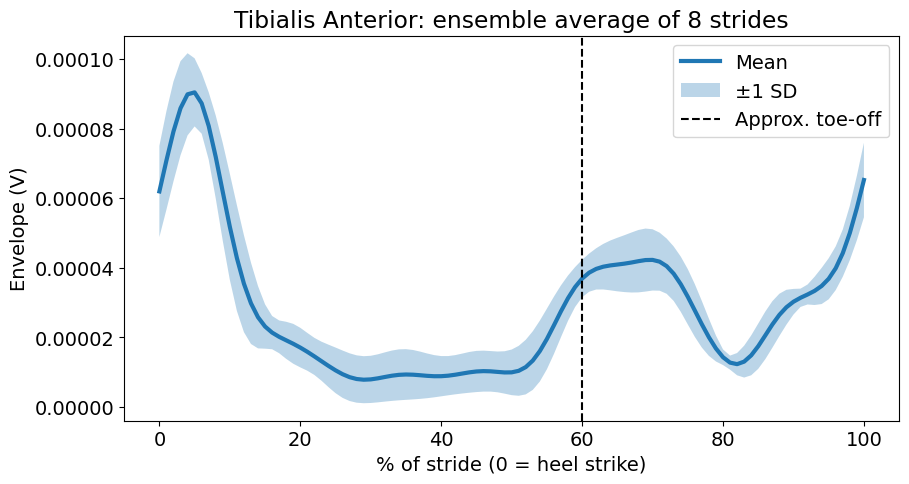

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(pct, mean_env, linewidth=3, label='Mean')
plt.fill_between(pct, mean_env - sd_env, mean_env + sd_env, alpha=0.3, label='±1 SD')
plt.axvline(60, color='black', linestyle='--', label='Approx. toe-off')
plt.xlabel('% of stride (0 = heel strike)')
plt.ylabel('Envelope (V)')
plt.title(f'{MUSCLE}: ensemble average of {strides.shape[0]} strides')
plt.legend()
plt.show()

### ✅ Checkpoint 5
- The mean curve is smooth, and the SD band is narrower than the peaks of the mean.

**Question 5.1:** At which % of the stride is the Tibialis Anterior most active? Is this in stance or in swing? Why does the body need this muscle at that time?

---
## Part 6 - Repeat the analysis for the other muscles

### 6a. Change one variable
1. Go to the cell at the start of **Part 3** and change `MUSCLE` to `'Soleus'`.
2. Run all the cells from that cell to the end of **Part 5** again. (In Jupyter: click the `MUSCLE` cell, then **Run → Run Selected Cell and All Below**. In Colab: **Runtime → Run after**.)
3. Do the checkpoints again. Then do the same for `'Gastrocnemius Lateral'` and `'Gastrocnemius Medial'`.

**Question 6.1:** Why do you **not** need to run Parts 1 and 2 again for a different muscle?

### 6b. Put the pipeline in a function

Running the cells again for each muscle is slow, and it is easy to make a mistake. A better method is to put Parts 3 to 5 in **one function** and call it for each muscle.

Complete the function `analyze_muscle()`. Copy your code from Parts 3, 4, and 5. The function must return `mean_env`, `sd_env`, and `strides` for the muscle that you give it.

In [20]:
#  TODO - Part 6b
def analyze_muscle(muscle_name):
    '''Run Parts 3-5 for one muscle. Uses hs_idx_emg and t_emg from Parts 1-2.'''
    # Part 3: load the sensor and compute the envelope
    sensor = load_sensor(data, MUSCLES[muscle_name])
    emg_env = process_emg(sensor['emg'], sensor['fs_emg']) #*

    # Part 4: cut and normalize the strides (copy your loop from Part 4)
    pct = np.linspace(0, 100, 101)
    strides = []
    for k in range(len(hs_idx_emg) - 1):
        start = hs_idx_emg[k]
        end = hs_idx_emg[k + 1]
        stride_time = t_emg[end] - t_emg[start]
        # 4a. Skip the stride if it is shorter than MIN_STRIDE or longer than MAX_STRIDE
        if (stride_time<MIN_STRIDE) or (stride_time>MAX_STRIDE): #*
            continue
    
        # 4b. Cut the envelope of this stride (from start to end)
        segment = emg_env[start:end] #*
    
        # 4c. Normalize to 101 points (hint: np.interp(pct, original_pct, segment))
        original_pct = np.linspace(0, 100, len(segment))
        segment_norm = np.interp(pct, original_pct, segment)
    
        strides.append(segment_norm)
    

    strides = np.array(strides)

    # Part 5: ensemble average
    mean_env = np.mean(strides, axis = 0)
    sd_env = np.std(strides, axis = 0 )
    return mean_env, sd_env, strides

### 6c. Compare all muscles in one plot

Each sensor touches the skin in a different way, so the EMG amplitude (in volts) of two muscles **cannot** be compared directly. To compare the **timing**, we divide each mean curve by its own peak. Now each curve goes from 0 to 100% of its maximum.

Run the next cell. If your function is correct, you see four curves.

(101,)
(101,)
(101,)
(101,)


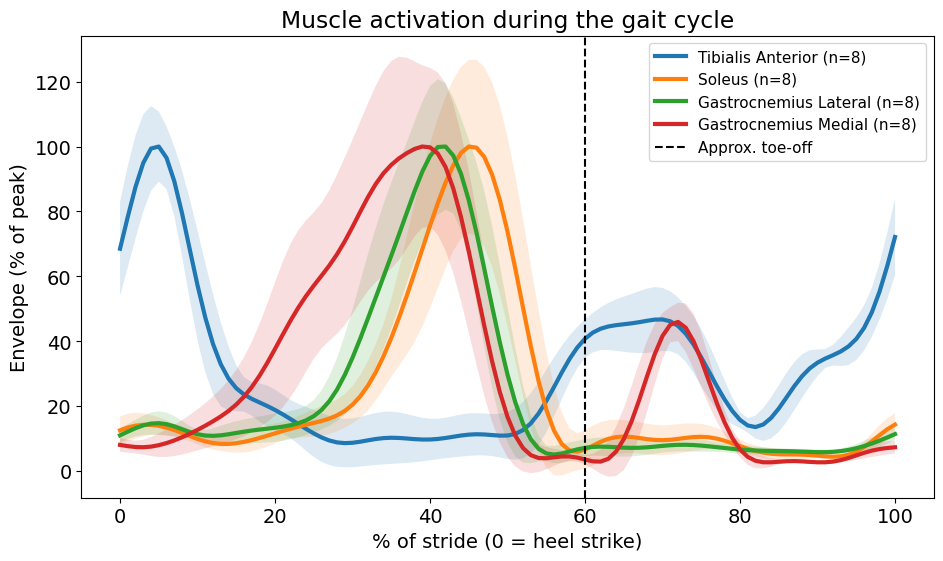

In [23]:
plt.figure(figsize=(11, 6))
for muscle_name in MUSCLES:
    m, s, st = analyze_muscle(muscle_name)
    print(m.shape)
    peak = m.max()
    plt.plot(pct, 100 * m / peak, linewidth=3, label=f'{muscle_name} (n={st.shape[0]})')
    plt.fill_between(pct, 100 * (m - s) / peak, 100 * (m + s) / peak, alpha=0.15)

plt.axvline(60, color='black', linestyle='--', label='Approx. toe-off')
plt.xlabel('% of stride (0 = heel strike)')
plt.ylabel('Envelope (% of peak)')
plt.title('Muscle activation during the gait cycle')
plt.legend(fontsize=11, loc='upper right')
plt.show()

### ✅ Checkpoint 6
- You see four curves, and each curve has a maximum of 100%.
- The Tibialis Anterior curve is the same as in Part 5 (but now in % of its peak).

### 6d. Questions

Write your answers in the cell below.

1. Which muscle(s) have their peak activity **in late stance, before toe-off** (about 40 to 55% of the stride)? What is their function at this time?
2. Which muscle is active **around heel strike and in swing**? Do the plantarflexors and the Tibialis Anterior work at the same time or at different times? Why?
3. The Soleus and the two Gastrocnemius muscles have a similar pattern. Why? Do they reach their peak at exactly the same time?
4. Which muscle has the **largest variability** between strides (the widest SD band)?
5. Go back to Part 1 and change the low-pass cutoff from 20 Hz to **5 Hz**. Run Part 1 again. What happens to the heel strike detection? Explain with what you learned in 03.03. (Change the cutoff back to 20 Hz after this question.)
6. **Optional challenge:** Use `hs_times` to compute the mean stride time, the SD of the stride time, and the cadence (steps per minute) of this participant. Use only the strides between 0.9 s and 2.0 s. (Hint: one stride has two steps.)

In [ ]:
# Your answers / code for 6d

---
## Key Takeaways

- Signals recorded at **different sampling rates** must be aligned with **time**, not with sample numbers.
- **Process the full signal first**, then cut it into cycles, to avoid filter errors at the edges.
- A **quality check** (for example, a valid stride duration) removes the cycles that are not correct. Real data always has some.
- Time normalization (0 to 100%) and ensemble averaging show the **typical activation pattern** of each muscle.
- When you put a pipeline in a **function**, you can repeat the same analysis on many muscles, participants, or conditions with no copy-and-paste errors.